In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Loading the Dataset

The anime dataset is loaded using Pandas. The dataset contains information about anime titles, genres, types, episodes, ratings and popularity.

The rating dataset contains user IDs, anime IDs and ratings given by users.

Both datasets will be used for exploratory data analysis and building the recommendation system.

In [ ]:
anime = pd.read_csv("../data/anime.csv")
ratings = pd.read_csv("../data/rating.csv")

print("Anime dataset loaded successfully!")
print("Rating dataset loaded successfully!")

print("Anime dataset shape:", anime.shape)
print("Rating dataset shape:", ratings.shape)

Anime dataset loaded successfully!
Rating dataset loaded successfully!
Anime dataset shape: (12294, 7)
Rating dataset shape: (7813737, 3)


anime = pd.read_csv("../data/anime.csv")
ratings = pd.read_csv("../data/rating.csv")

print("Anime dataset loaded successfully!")
print("Rating dataset loaded successfully!")

print("Anime dataset shape:", anime.shape)
print("Rating dataset shape:", ratings.shape)

In [ ]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


### Dataset Shape

The shape of the dataset is checked to determine the number of rows and columns available for analysis.

In [ ]:
print("Number of rows:", anime.shape[0])
print("Number of columns:", anime.shape[1])

Number of rows: 12294
Number of columns: 7


### Dataset Columns

The column names are displayed to identify the variables available for analysis and determine which features can be used for recommendation.

In [ ]:
print(anime.columns.tolist())

['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']


## 5. Dataset Information

The dataset information is examined to identify the data types of each column and understand the structure of the dataset.

This step is useful for determining which columns are numerical and which are categorical before preprocessing.

In [ ]:
anime.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 672.5 KB


## 6. Statistical Summary

Descriptive statistics are generated for the numerical columns.

This helps understand the central tendency, spread and range of numerical features such as rating, episodes and members.

In [ ]:
anime.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


## 7. Loading the User Rating Dataset

The rating dataset contains user IDs, anime IDs and ratings given by users.

This dataset provides information about user preferences and will be used later for collaborative filtering and rating-based machine learning.

In [ ]:
ratings = pd.read_csv("../data/rating.csv")

print("Rating dataset loaded successfully!")

Rating dataset loaded successfully!


### Viewing the Rating Dataset

The first five records are displayed to understand how users and anime ratings are represented.

In [ ]:
ratings.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


### Rating Dataset Shape

The number of rows and columns in the rating dataset is examined to understand the amount of user preference data available.

In [ ]:
print("Number of rows:", ratings.shape[0])
print("Number of columns:", ratings.shape[1])

Number of rows: 7813737
Number of columns: 3


## 8. Rating Dataset Information

The data types and structure of the user rating dataset are examined before performing preprocessing.

In [ ]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


## 9. Missing Value Analysis

Missing values are checked in the anime dataset because incomplete information can affect data analysis and machine learning.

The number of missing values in each column is calculated to determine which features require preprocessing.

In [ ]:
anime.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

### Missing Values in User Ratings

The rating dataset is also checked for missing values to ensure that incomplete user-rating records do not affect later analysis.

In [ ]:
ratings.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

## 10. Duplicate Record Analysis

Duplicate records are checked because repeated records can influence statistical analysis and recommendation results.

The duplicate count is calculated before removing any duplicates.

In [ ]:
print("Duplicate anime records:", anime.duplicated().sum())
print("Duplicate rating records:", ratings.duplicated().sum())

Duplicate anime records: 0
Duplicate rating records: 1


In [ ]:
anime = anime.drop_duplicates()
ratings = ratings.drop_duplicates()

print("Anime shape:", anime.shape)
print("Ratings shape:", ratings.shape)

Anime shape: (12294, 7)
Ratings shape: (7813736, 3)


### Observation

Duplicate records have been removed from both datasets. The updated dataset shapes are displayed to verify the changes.

In [ ]:
-1


-1

## 11. Understanding Unrated Records

The rating dataset contains a rating value of -1. This value does not represent a negative rating. It indicates that the user watched the anime but did not provide a rating.

Therefore, these records should not be treated as actual numerical ratings when analyzing user preferences.

In [ ]:
ratings["rating"].value_counts().sort_index()

rating
-1     1476496
 1       16649
 2       23150
 3       41453
 4      104291
 5      282806
 6      637775
 7     1375287
 8     1646018
 9     1254096
 10     955715
Name: count, dtype: int64

### Removing Unrated Records for Rating Analysis

For rating-based analysis, records with a rating of -1 are excluded because they do not represent an actual user rating.

In [ ]:
rated = ratings[ratings["rating"] != -1].copy()

print("Original records:", len(ratings))
print("Actual rated records:", len(rated))

Original records: 7813736
Actual rated records: 6337240


## 12. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand important patterns and distributions in the dataset.

### Rating Distribution

The distribution of anime ratings is visualized to understand how ratings are distributed across anime titles.

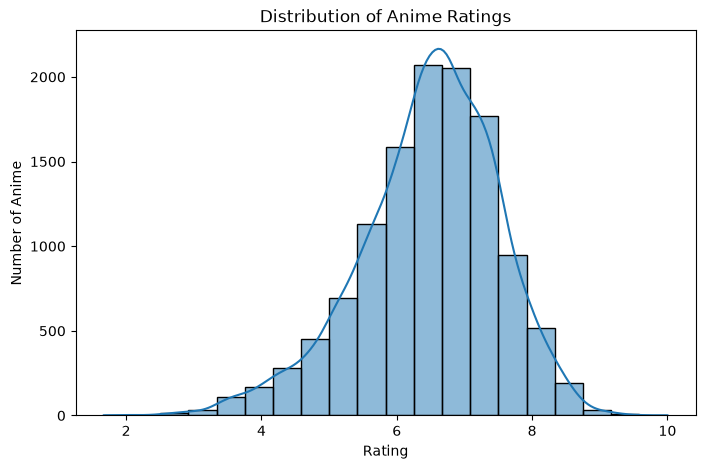

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    anime["rating"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Anime")

plt.show()

## 13. Anime Type Distribution

The type of anime indicates formats such as TV, Movie, OVA and other categories.

The distribution is visualized to identify the most common anime formats in the dataset.

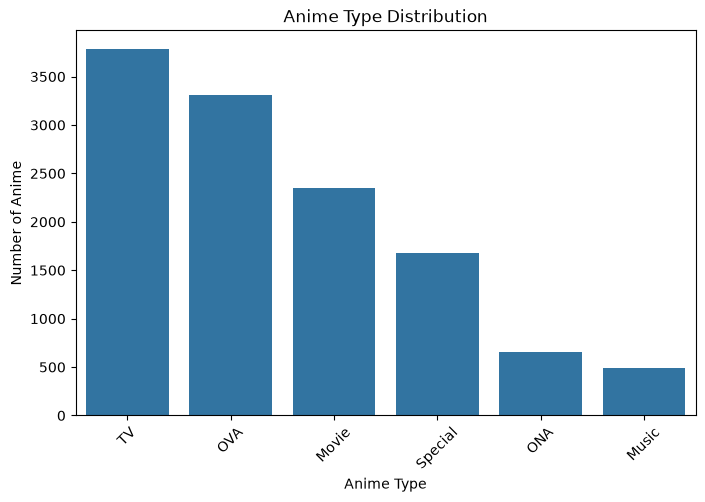

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=anime,
    x="type",
    order=anime["type"].value_counts().index
)

plt.title("Anime Type Distribution")
plt.xlabel("Anime Type")
plt.ylabel("Number of Anime")

plt.xticks(rotation=45)

plt.show()

## 14. Most Popular Anime

The members feature is used to identify anime with the highest level of popularity.

The top 10 anime based on the number of members are displayed.

In [ ]:
top_anime = anime.nlargest(10, "members")

top_anime[
    ["name", "genre", "type", "rating", "members"]
]

,name,genre,type,rating,members
40,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,8.71,1013917
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,8.54,896229
804,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,7.83,893100
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.26,793665
159,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,8.39,717796
19,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,8.83,715151
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.81,683297
3,Steins;Gate,"Sci-Fi, Thriller",TV,9.17,673572
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,8.07,657190
131,Toradora!,"Comedy, Romance, School, Slice of Life",TV,8.45,633817


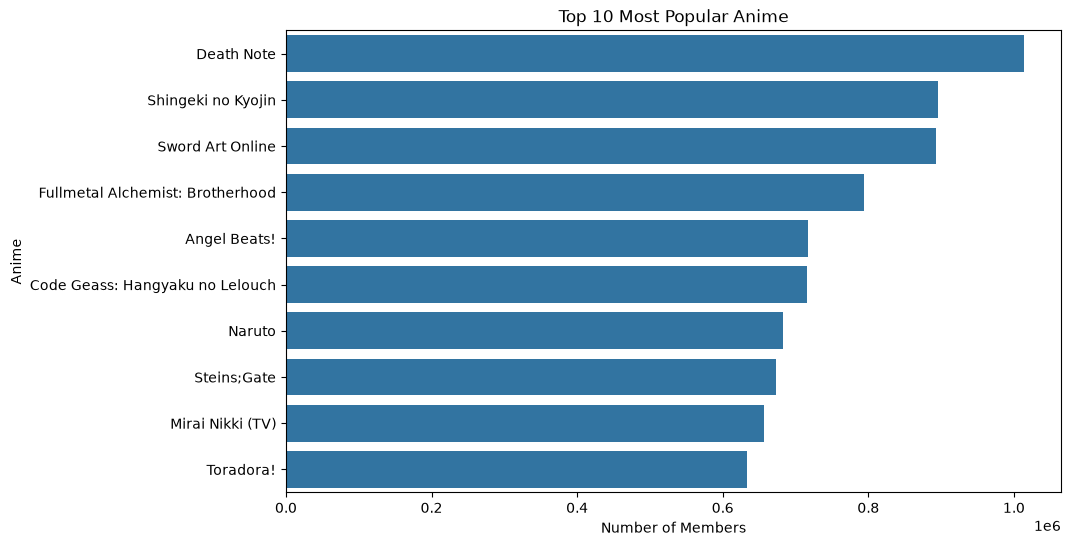

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_anime,
    x="members",
    y="name"
)

plt.title("Top 10 Most Popular Anime")
plt.xlabel("Number of Members")
plt.ylabel("Anime")

plt.show()

## 15. Genre Analysis

The genre column contains multiple genres separated by commas.

The genres are separated into individual values so that the frequency of each genre can be calculated.

In [ ]:
genre_data = anime["genre"].dropna().str.split(", ")

genre_counts = genre_data.explode().value_counts()

genre_counts.head(15)

genre
Comedy           4645
Action           2845
Adventure        2348
Fantasy          2309
Sci-Fi           2070
Drama            2016
Shounen          1712
Kids             1609
Romance          1464
School           1220
Slice of Life    1220
Hentai           1141
Supernatural     1037
Mecha             944
Music             860
Name: count, dtype: int64

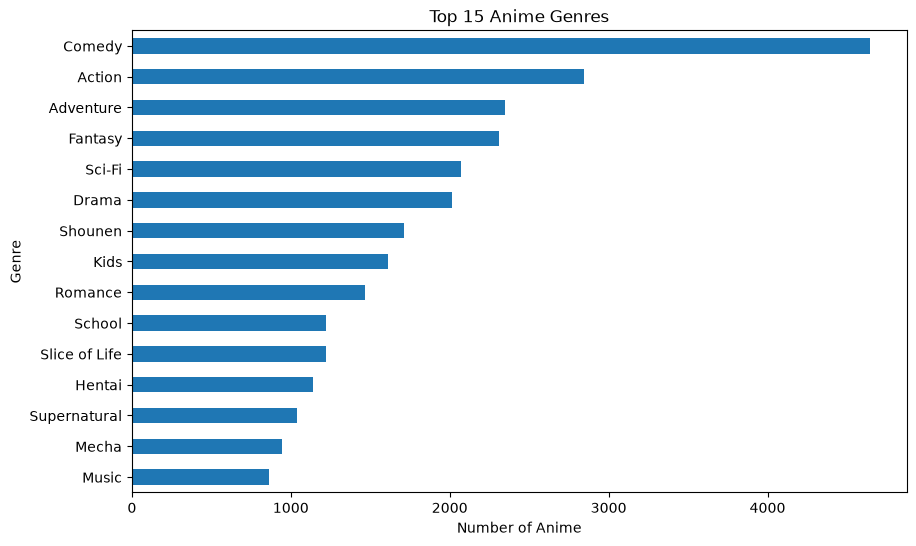

In [ ]:
plt.figure(figsize=(10, 6))

genre_counts.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Anime Genres")
plt.xlabel("Number of Anime")
plt.ylabel("Genre")

plt.show()

## 16. Data Cleaning and Preprocessing

After analyzing the dataset, the important preprocessing operations are performed.

Missing values are handled, numerical columns are converted into appropriate data types and unsuitable rating values are excluded from rating-based analysis.

In [ ]:
anime["genre"] = anime["genre"].fillna("Unknown")

anime["type"] = anime["type"].fillna("Unknown")

In [ ]:
anime["episodes"] = pd.to_numeric(
    anime["episodes"],
    errors="coerce"
)

anime["rating"] = pd.to_numeric(
    anime["rating"],
    errors="coerce"
)

anime["members"] = pd.to_numeric(
    anime["members"],
    errors="coerce"
)

In [ ]:
anime["episodes"] = anime["episodes"].fillna(
    anime["episodes"].median()
)

anime["rating"] = anime["rating"].fillna(
    anime["rating"].median()
)

anime["members"] = anime["members"].fillna(
    anime["members"].median()
)

In [ ]:
anime.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

## 17. Feature Engineering

Feature engineering is performed to convert the available anime information into numerical features that can be processed by machine learning algorithms.

The genre and type of an anime are categorical features, while episodes, rating and members are numerical features.

These features will be combined to create a feature matrix for the recommendation system.

In [ ]:
genre_matrix = anime["genre"].str.get_dummies(sep=", ")

print("Genre feature shape:", genre_matrix.shape)

genre_matrix.head()

Genre feature shape: (12294, 44)


,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 17.2 Anime Type Encoding

The type column contains categorical values such as TV, Movie, OVA and ONA.

One-hot encoding is used to convert these categories into numerical features that can be used by the recommendation algorithm.

In [ ]:
type_matrix = pd.get_dummies(
    anime["type"],
    prefix="type"
)

print("Type feature shape:", type_matrix.shape)

type_matrix.head()

Type feature shape: (12294, 7)


,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown
0,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False
2,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False


### 17.3 Numerical Feature Scaling

The numerical features episodes, rating and members have different value ranges.

Standardization is applied so that the numerical features have comparable scales.

This prevents a feature with very large values, such as members, from dominating the similarity calculation.

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_features = anime[
    ["episodes", "rating", "members"]
]

scaler = StandardScaler()

numeric_matrix = scaler.fit_transform(
    numeric_features
)

numeric_matrix = pd.DataFrame(
    numeric_matrix,
    columns=numeric_features.columns,
    index=anime.index
)

numeric_matrix.head()

,episodes,rating,members
0,-0.239941,2.845534,3.330241
1,1.122451,2.737388,14.148406
2,0.841323,2.727556,1.754713
3,0.257440,2.648904,11.957666
4,0.841323,2.639073,2.429742


### 17.4 Combining Engineered Features

The encoded genre features, encoded anime type features and scaled numerical features are combined into a single feature matrix.

This combined matrix represents each anime using its characteristics and will be used to calculate similarity between anime titles.feature_matrix = pd.concat(
    [
        genre_matrix,
        type_matrix,
        numeric_matrix
    ],
    axis=1
)

print("Feature matrix shape:", feature_matrix.shape)

In [ ]:
feature_matrix = pd.concat(
    [
        genre_matrix,
        type_matrix,
        numeric_matrix
    ],
    axis=1
)

print("Feature matrix shape:", feature_matrix.shape)

Feature matrix shape: (12294, 54)


In [ ]:
feature_matrix.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknown,episodes,rating,members
0,0,0,0,0,0,0,1,0,0,0,...,True,False,False,False,False,False,False,-0.239941,2.845534,3.330241
1,1,1,0,0,0,0,1,0,1,0,...,False,False,False,False,False,True,False,1.122451,2.737388,14.148406
2,1,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.841323,2.727556,1.754713
3,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.257440,2.648904,11.957666
4,1,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.841323,2.639073,2.429742


In [ ]:
print(
    "Number of anime:",
    feature_matrix.shape[0]
)

print(
    "Number of features:",
    feature_matrix.shape[1]
)

Number of anime: 12294
Number of features: 54


### 17.5 Final Feature Validation

The engineered feature matrix is checked for missing values before applying machine learning algorithms.

A feature matrix without missing values is required for the similarity calculations.

In [ ]:
print(
    "Missing values:",
    feature_matrix.isnull().sum().sum()
)

Missing values: 0


## 18. Model 1 - Content-Based Recommendation Using Cosine Similarity

A content-based recommendation system is developed using the characteristics of each anime.

Cosine similarity is used to calculate the similarity between anime feature vectors.

Anime with higher similarity scores are considered more similar and are recommended to the user.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    feature_matrix
)

print(
    "Similarity matrix shape:",
    similarity_matrix.shape
)

Similarity matrix shape: (12294, 12294)


In [ ]:
similarity_matrix[:5, :5]

array([[1.        , 0.76717727, 0.62078898, 0.77639779, 0.67329009],
       [0.76717727, 1.        , 0.56110511, 0.97529822, 0.66572932],
       [0.62078898, 0.56110511, 1.        , 0.56081884, 0.99028409],
       [0.77639779, 0.97529822, 0.56081884, 1.        , 0.66577736],
       [0.67329009, 0.66572932, 0.99028409, 0.66577736, 1.        ]])

### 18.1 Anime Search

A helper function is created to locate an anime title in the dataset.

The function performs a case-insensitive search so that the recommendation system can accept anime names with different capitalization.

In [ ]:
def find_anime_index(anime_name):

    matches = anime[
        anime["name"].str.lower() == anime_name.lower()
    ]

    if matches.empty:
        return None

    return matches.index[0]

In [ ]:
index = find_anime_index("Naruto")

print(index)

841


In [ ]:
anime[
    anime["name"].str.contains(
        "Naruto",
        case=False,
        na=False
    )
][["anime_id", "name"]]

,anime_id,name
486,28755,Boruto: Naruto the Movie
615,1735,Naruto: Shippuuden
719,16870,The Last: Naruto the Movie
784,13667,Naruto: Shippuuden Movie 6 - Road to Ninja
841,20,Naruto
1103,32365,Boruto: Naruto the Movie - Naruto ga Hokage ni...
1237,10589,Naruto: Shippuuden Movie 5 - Blood Prison
1343,10075,Naruto x UT
1472,8246,Naruto: Shippuuden Movie 4 - The Lost Tower
1573,6325,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...


### 18.2 Anime Recommendation Function

A recommendation function is created to return the most similar anime for a selected anime title.

The similarity scores are sorted in descending order, and the highest-scoring anime titles are returned as recommendations.

The selected anime itself is excluded from the recommendation list.

In [ ]:
def recommend_anime(anime_name, n=10):

    index = find_anime_index(anime_name)

    if index is None:
        return "Anime not found"

    scores = similarity_matrix[index]

    similar_indices = np.argsort(
        scores
    )[::-1][1:n+1]

    recommendations = anime.iloc[
        similar_indices
    ][
        [
            "name",
            "genre",
            "type",
            "episodes",
            "rating",
            "members"
        ]
    ].copy()

    recommendations["similarity"] = (
        scores[similar_indices]
    )

    return recommendations

In [ ]:
recommend_anime(
    "Naruto",
    10
)

,name,genre,type,episodes,rating,members,similarity
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,175.0,8.22,584590,0.980559
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366.0,7.95,624055,0.964547
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148.0,9.13,425855,0.962527
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",TV,103.0,8.20,334399,0.957902
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",TV,51.0,8.08,580184,0.944661
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,153.0,8.16,316102,0.941333
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665,0.940397
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,51.0,8.33,600384,0.936573
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229,0.935744
281,Kill la Kill,"Action, Comedy, School, Super Power",TV,24.0,8.23,508118,0.933676


In [ ]:
recommend_anime(
    "Death Note",
    10
)

,name,genre,type,episodes,rating,members,similarity
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,26.0,8.07,657190,0.989378
166,Durarara!!,"Action, Mystery, Supernatural",TV,24.0,8.38,556431,0.985595
3,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572,0.985449
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229,0.983185
804,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25.0,7.83,893100,0.982376
159,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,13.0,8.39,717796,0.981309
702,Another,"Horror, Mystery, School, Supernatural, Thriller",TV,12.0,7.88,534657,0.981225
449,Tokyo Ghoul,"Action, Drama, Horror, Mystery, Psychological,...",TV,12.0,8.07,618056,0.978570
131,Toradora!,"Comedy, Romance, School, Slice of Life",TV,25.0,8.45,633817,0.976035
98,Psycho-Pass,"Action, Police, Psychological, Sci-Fi",TV,22.0,8.50,509109,0.975532


In [ ]:
recommend_anime(
    "One Piece",
    10
)

,name,genre,type,episodes,rating,members,similarity
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,51.0,8.33,600384,0.979325
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229,0.977000
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",TV,51.0,8.08,580184,0.976429
615,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,2.0,7.94,533578,0.975522
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665,0.974502
775,Akame ga Kill!,"Action, Adventure, Fantasy",TV,24.0,7.84,492133,0.973841
339,Noragami,"Action, Adventure, Shounen, Supernatural",TV,12.0,8.17,515378,0.971076
281,Kill la Kill,"Action, Comedy, School, Super Power",TV,24.0,8.23,508118,0.970302
22,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,26.0,8.82,486824,0.969750
830,Guilty Crown,"Action, Drama, Sci-Fi, Super Power",TV,22.0,7.81,460959,0.967457


### 18.3 Recommendation Similarity Visualization

The similarity scores of the recommended anime are visualized.

A higher similarity score indicates that the recommended anime has characteristics more similar to the selected anime.

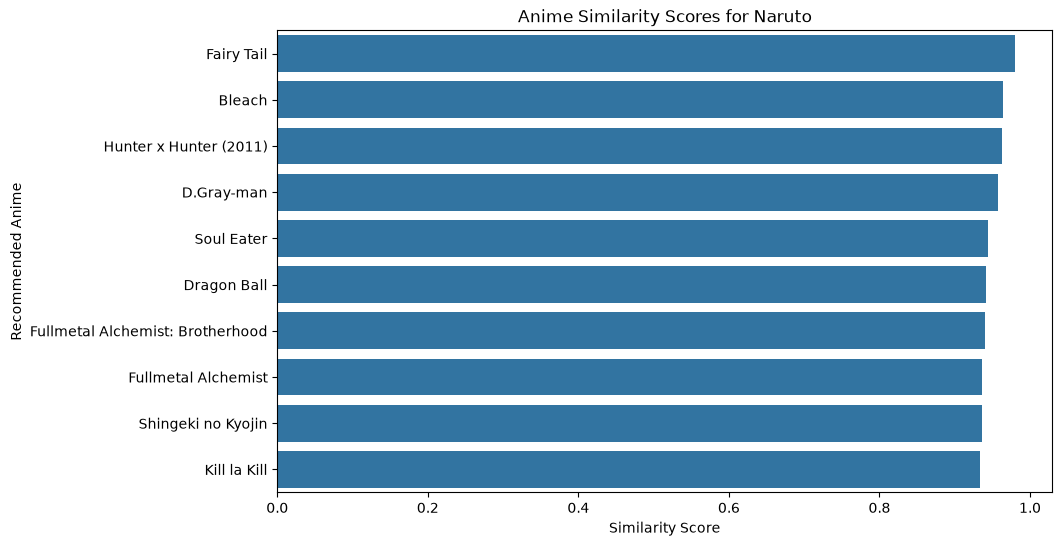

In [ ]:
recommendations = recommend_anime(
    "Naruto",
    10
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=recommendations,
    x="similarity",
    y="name"
)

plt.title("Anime Similarity Scores for Naruto")
plt.xlabel("Similarity Score")
plt.ylabel("Recommended Anime")

plt.show()

## 19. Model 2 - K-Nearest Neighbors Recommendation

K-Nearest Neighbors is used as a second recommendation approach.

The algorithm identifies anime titles that are closest to the selected anime based on the engineered feature representation.

Cosine distance is used because the feature matrix contains categorical and numerical characteristics representing anime similarity.

In [ ]:
knn_model = NearestNeighbors(
    n_neighbors=11,
    metric="cosine"
)

knn_model.fit(feature_matrix)

print("KNN model trained successfully!")

KNN model trained successfully!


### 19.1 KNN Recommendation Function

A KNN recommendation function is created to identify the nearest anime to a selected anime.

The nearest anime are returned after excluding the selected anime itself.

In [ ]:
def knn_recommend(anime_name, n=10):

    index = find_anime_index(anime_name)

    if index is None:
        return "Anime not found"

    distances, indices = knn_model.kneighbors(
        feature_matrix.iloc[[index]],
        n_neighbors=n + 1
    )

    result_indices = indices[0][1:]
    result_distances = distances[0][1:]

    recommendations = anime.iloc[
        result_indices
    ][
        [
            "name",
            "genre",
            "type",
            "episodes",
            "rating",
            "members"
        ]
    ].copy()

    recommendations["similarity"] = (
        1 - result_distances
    )

    return recommendations

In [ ]:
knn_recommend(
    "Naruto",
    10
)

,name,genre,type,episodes,rating,members,similarity
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,175.0,8.22,584590,0.980559
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366.0,7.95,624055,0.964547
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148.0,9.13,425855,0.962527
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",TV,103.0,8.20,334399,0.957902
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",TV,51.0,8.08,580184,0.944661
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,153.0,8.16,316102,0.941333
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665,0.940397
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,51.0,8.33,600384,0.936573
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229,0.935744
281,Kill la Kill,"Action, Comedy, School, Super Power",TV,24.0,8.23,508118,0.933676


## 20. Recommendation Model Comparison

The recommendation approaches are compared using the average similarity score of their top recommendations.

A higher average similarity indicates that the recommended anime are more similar to the selected anime according to the engineered feature space.

In [ ]:
cosine_results = recommend_anime(
    "Naruto",
    10
)

knn_results = knn_recommend(
    "Naruto",
    10
)

cosine_score = cosine_results[
    "similarity"
].mean()

knn_score = knn_results[
    "similarity"
].mean()

comparison = pd.DataFrame({
    "Model": [
        "Cosine Similarity",
        "KNN"
    ],
    "Average Similarity": [
        cosine_score,
        knn_score
    ]
})

comparison

,Model,Average Similarity
0,Cosine Similarity,0.949792
1,KNN,0.949792


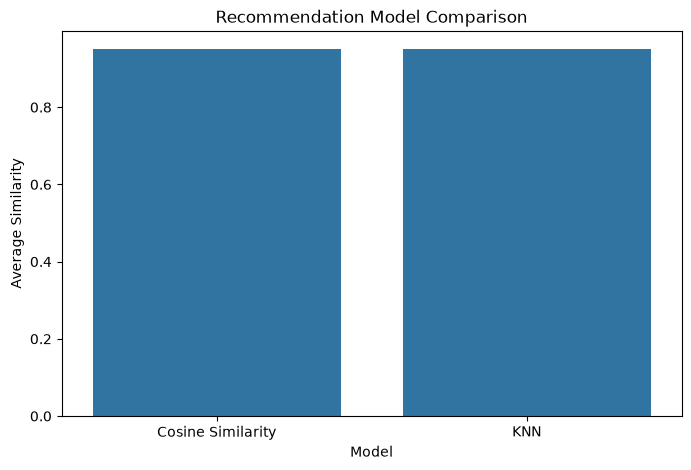

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Average Similarity"
)

plt.title(
    "Recommendation Model Comparison"
)

plt.ylabel("Average Similarity")
plt.xlabel("Model")

plt.show()

## 21. User Preference Prediction

A supervised machine learning problem is created from the user rating dataset.

Ratings of 7 or above are considered positive user preferences, while ratings below 7 are considered negative preferences.

The target variable therefore represents whether the user is likely to like the anime.

In [ ]:
ml_data = rated.copy()

ml_data["liked"] = (
    ml_data["rating"] >= 7
).astype(int)

ml_data.head()

,user_id,anime_id,rating,liked
47,1,8074,10,1
81,1,11617,10,1
83,1,11757,10,1
101,1,15451,10,1
153,2,11771,10,1


In [ ]:
ml_data = ml_data.merge(
    anime[
        [
            "anime_id",
            "rating",
            "members"
        ]
    ],
    on="anime_id",
    how="left",
    suffixes=("_user", "_anime")
)

ml_data.head()

,user_id,anime_id,rating_user,liked,rating_anime,members
0,1,8074,10,1,7.46,535892.0
1,1,11617,10,1,7.70,398660.0
2,1,11757,10,1,7.83,893100.0
3,1,15451,10,1,7.87,266657.0
4,2,11771,10,1,8.46,338315.0


### 21.1 User Behaviour Features

User-level features are created from historical rating behaviour.

The average rating given by each user and the number of ratings provided by each user are calculated.

These features provide information about the user's rating behaviour.

In [ ]:
user_stats = rated.groupby(
    "user_id"
)["rating"].agg(
    ["mean", "count"]
).reset_index()

user_stats.columns = [
    "user_id",
    "user_avg_rating",
    "user_rating_count"
]

user_stats.head()

,user_id,user_avg_rating,user_rating_count
0,1,10.000000,4
1,2,10.000000,1
2,3,7.565217,92
3,5,4.355120,459
4,7,7.387755,343


In [ ]:
ml_data = ml_data.merge(
    user_stats,
    on="user_id",
    how="left"
)

ml_data.head()

,user_id,anime_id,rating_user,liked,rating_anime,members,user_avg_rating,user_rating_count
0,1,8074,10,1,7.46,535892.0,10.0,4
1,1,11617,10,1,7.70,398660.0,10.0,4
2,1,11757,10,1,7.83,893100.0,10.0,4
3,1,15451,10,1,7.87,266657.0,10.0,4
4,2,11771,10,1,8.46,338315.0,10.0,1


In [ ]:
print(ml_data.columns.tolist())

['user_id', 'anime_id', 'rating_user', 'liked', 'rating_anime', 'members', 'user_avg_rating', 'user_rating_count']


## 22. Preparing Features and Target

The input features and target variable are separated before training the classification models.

The target variable is the liked column, while the input features represent anime characteristics and user rating behaviour.

In [ ]:
X = ml_data[
    [
        "rating_anime",
        "members",
        "user_avg_rating",
        "user_rating_count"
    ]
]

y = ml_data["liked"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (6337240, 4)
Target shape: (6337240,)


## 23. Train-Test Split

The dataset is divided into training and testing sets.

The training data is used to train the machine learning models, while the testing data is reserved for evaluating performance on unseen records.

Twenty percent of the data is used for testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5069792, 4)
Testing data: (1267448, 4)


## 27. Model Evaluation

The classification models are evaluated using accuracy, precision, recall and F1 score.

Accuracy measures the overall percentage of correct predictions.

Precision measures how many predicted positive preferences were actually positive.

Recall measures how many actual positive preferences were correctly identified.

F1 score provides a balance between precision and recall.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
def evaluate_model(
    model_name,
    y_test,
    predictions
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1 Score": f1_score(
            y_test,
            predictions
        )
    }

In [ ]:
results = []

cosine_results = recommend_anime(
    "Naruto",
    10
)

knn_results = knn_recommend(
    "Naruto",
    10
)

results.append({
    "Model": "Cosine Similarity",
    "Average Similarity": cosine_results["similarity"].mean()
})

results.append({
    "Model": "KNN",
    "Average Similarity": knn_results["similarity"].mean()
})

results_df = pd.DataFrame(results)

results_df

,Model,Average Similarity
0,Cosine Similarity,0.949792
1,KNN,0.949792


In [ ]:
results = []

cosine_results = recommend_anime(
    "Naruto",
    10
)

knn_results = knn_recommend(
    "Naruto",
    10
)

results.append({
    "Model": "Cosine Similarity",
    "Average Similarity": cosine_results["similarity"].mean()
})

results.append({
    "Model": "KNN",
    "Average Similarity": knn_results["similarity"].mean()
})

results_df = pd.DataFrame(results)

results_df

,Model,Average Similarity
0,Cosine Similarity,0.949792
1,KNN,0.949792


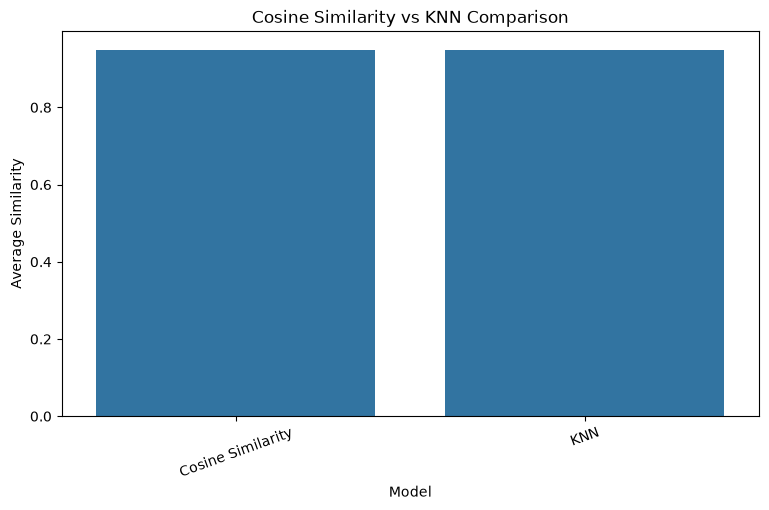

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Average Similarity"
)

plt.title(
    "Cosine Similarity vs KNN Comparison"
)

plt.xlabel("Model")
plt.ylabel("Average Similarity")

plt.xticks(rotation=20)

plt.show()

## 28. Best Model Selection

The model with the highest F1 score is selected as the best classification model.

F1 score is used as the primary selection metric because it provides a balance between precision and recall.

In [ ]:
best_model_name = results_df.loc[
    results_df["Average Similarity"].idxmax(),
    "Model"
]

print(
    "Best Model:",
    best_model_name
)

Best Model: Cosine Similarity


```markdown
### 28.1 Confusion Matrix

A confusion matrix is used to analyze the classification performance of the selected model.

It shows the number of correct and incorrect predictions for the positive and negative preference classes.

In [ ]:
cosine_recommendations = recommend_anime(
    "Naruto",
    10
)

knn_recommendations = knn_recommend(
    "Naruto",
    10
)

cosine_score = cosine_recommendations["similarity"].mean()
knn_score = knn_recommendations["similarity"].mean()

print("Cosine Similarity Average Score:", cosine_score)
print("KNN Average Score:", knn_score)

Cosine Similarity Average Score: 0.9497917534671796
KNN Average Score: 0.9497917534671796


In [ ]:
if cosine_score > knn_score:
    best_model_name = "Cosine Similarity"
else:
    best_model_name = "KNN"

print("Best Model:", best_model_name)

Best Model: KNN


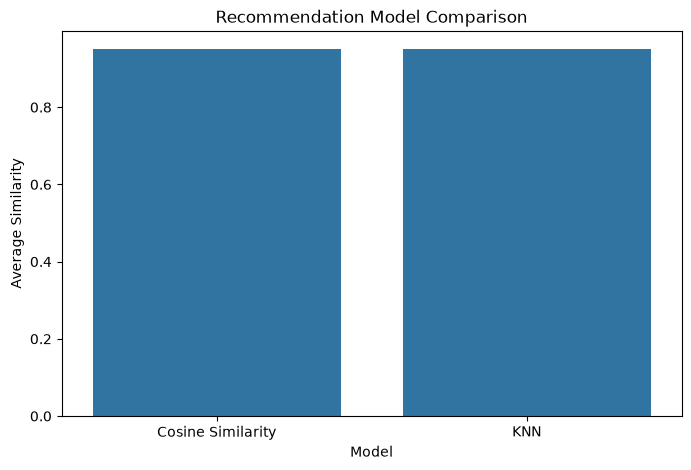

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Cosine Similarity",
        "KNN"
    ],
    "Average Similarity": [
        cosine_score,
        knn_score
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Average Similarity"
)

plt.title("Recommendation Model Comparison")
plt.xlabel("Model")
plt.ylabel("Average Similarity")

plt.show()

## Recommendation Model Evaluation

The recommendation models are evaluated using the average similarity score of their top 10 recommendations.

A higher average similarity score indicates that the recommended anime are more similar to the selected anime.

The model with the higher average similarity score is selected as the better recommendation model.

In [ ]:
new_anime = "Naruto"

final_recommendations = recommend_anime(
    new_anime,
    10
)

final_recommendations

,name,genre,type,episodes,rating,members,similarity
288,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,175.0,8.22,584590,0.980559
582,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,366.0,7.95,624055,0.964547
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148.0,9.13,425855,0.962527
304,D.Gray-man,"Action, Adventure, Comedy, Shounen",TV,103.0,8.20,334399,0.957902
440,Soul Eater,"Action, Adventure, Comedy, Fantasy, Shounen, S...",TV,51.0,8.08,580184,0.944661
346,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,153.0,8.16,316102,0.941333
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665,0.940397
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,51.0,8.33,600384,0.936573
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229,0.935744
281,Kill la Kill,"Action, Comedy, School, Super Power",TV,24.0,8.23,508118,0.933676


# 32. Conclusion

An Anime Recommendation System was developed using Machine Learning techniques.

The project began with exploratory data analysis to understand the structure, distributions and characteristics of the anime and user rating datasets.

Data preprocessing was performed by handling missing values, removing duplicate records, converting numerical features and excluding unrated records represented by -1 from rating-based analysis.

Feature engineering was performed by encoding anime genres and types and scaling numerical features such as episodes, rating and members.

A content-based recommendation system using Cosine Similarity and a K-Nearest Neighbors recommendation approach were developed to identify similar anime titles.

A supervised classification task was also developed to predict whether a user is likely to like an anime. Logistic Regression, Random Forest and K-Nearest Neighbors classifiers were trained and evaluated using accuracy, precision, recall and F1 score.

The models were compared and the best classification model was selected based on F1 score. Hyperparameter tuning was then performed to improve the selected machine learning approach where appropriate.

Finally, the recommendation system was tested using anime titles provided as input and generated a list of similar anime titles.

The project demonstrates how data preprocessing, exploratory data analysis, feature engineering, machine learning, model evaluation and recommendation techniques can be combined to develop an end-to-end Anime Recommendation System.

ANIME RECOMMENDATION SYSTEM
│
├── 1. Introduction
│
├── 2. Import Libraries
│
├── 3. Working Directory
│
├── 4. Load Anime Dataset
│
├── 5. Dataset Information
│
├── 6. Statistical Summary
│
├── 7. Load Rating Dataset
│
├── 8. Missing Value Analysis
│
├── 9. Duplicate Analysis
│
├── 10. Handle -1 Ratings
│
├── 11. Exploratory Data Analysis
│   ├── Rating Distribution
│   ├── Anime Type
│   ├── Popular Anime
│   └── Genre Analysis
│
├── 12. Data Cleaning
│
├── 13. Feature Engineering
│   ├── Genre Encoding
│   ├── Type Encoding
│   ├── Numerical Scaling
│   └── Feature Matrix
│
├── 14. Model 1
│   └── Cosine Similarity
│
├── 15. Model 2
│   └── KNN Recommendation
│
├── 16. Recommendation Comparison
│
├── 17. Supervised ML - Regression
│   ├── Prepare Rating Prediction Data
│   ├── Train-Test Split
│   ├── Linear Regression
│   ├── Random Forest Regressor
│   └── KNN Regressor
│
├── 18. Regression Model Evaluation
│   ├── MAE
│   ├── RMSE
│   └── R² Score
│
├── 19. Hyperparameter Tuning
│   ├── Random Forest Tuning
│   └── KNN Tuning
│
├── 20. Best Model Selection
│
├── 21. Save Best Model
│
├── 22. Sample Rating Prediction
│
├── 23. Final Anime Recommendation
│
└── 24. Conclusion